# Классификация текста с помощью BERT и сравнение с TF-IDF + Logistic Regression

**Автор:** Николай Атаманов  
**Курс:** Разработчик нейросетей  

## Аннотация

В данной работе исследуется задача автоматической классификации текстов.
Сравниваются два подхода:

1. Классический метод машинного обучения  
   TF-IDF + Logistic Regression

2. Современный метод глубокого обучения  
   BERT (Bidirectional Encoder Representations from Transformers)

Цель работы — сравнить качество классификации и показать преимущества
трансформерных моделей в задачах обработки естественного языка.


## 1. Введение
## 2. Установка и импорт библиотек
## 3. Теоретическая часть
## 4. Подготовка данных
## 5. Базовая модель: TF-IDF + Logistic Regression
## 6. Модель BERT
## 7. Обучение моделей
## 8. Оценка результатов
## 9. Анализ ошибок
## 10. Сохранение моделей
## 11. Выводы

# **1. Введение**
# Классификация текста с помощью BERT и сравнение с TF-IDF + Logistic Regression

**Автор:** Николай Атаманов  
**Курс:** Разработчик нейросетей  

## Аннотация

В данной работе исследуется задача автоматической классификации текстов.
Сравниваются два подхода:

1. Классический метод машинного обучения  
   TF-IDF + Logistic Regression

2. Современный метод глубокого обучения  
   BERT (Bidirectional Encoder Representations from Transformers)

Цель работы — сравнить качество классификации и показать преимущества
трансформерных моделей в задачах обработки естественного языка.

# **2. Установка и импорт библиотек**

In [ ]:
!pip install transformers
!pip install datasets
!pip install scikit-learn
!pip install seaborn
!pip install tqdm

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

from datasets import load_dataset


# **3. Теоретическая часть**

## Проблема классификации текста

Классификация текста — это задача автоматического отнесения текста к
одной из заранее заданных категорий.

Примеры:
- анализ тональности отзывов
- фильтрация спама
- классификация новостей

## Метод TF-IDF

TF-IDF (Term Frequency – Inverse Document Frequency) используется для
преобразования текста в числовой вектор.

Формула:

TF-IDF(t,d) = TF(t,d) × log(N / DF(t))

где:

TF — частота слова  
DF — количество документов с этим словом

### Математическая формализация TF-IDF

TF (Term Frequency) определяется как:

TF(t, d) = f(t, d) / Σ_k f(k, d)

где:
- f(t, d) — количество вхождений слова t в документ d

IDF (Inverse Document Frequency):

IDF(t) = log(N / DF(t))

где:
- N — общее количество документов
- DF(t) — количество документов, содержащих слово t

Итоговая формула:

TF-IDF(t, d) = TF(t, d) × IDF(t)

## Логистическая регрессия

Логистическая регрессия используется для бинарной классификации и оценивает вероятность принадлежности объекта к классу.

Вероятность определяется как:

P(y = 1 | x) = σ(wᵀx + b)

где σ(z) — сигмоидная функция:

σ(z) = 1 / (1 + e^{-z})

Функция потерь (логистическая):

L = -1/N Σ [y log(p) + (1 - y) log(1 - p)]

где:
- p — предсказанная вероятность
- y — истинная метка класса

## Модель BERT

BERT — это трансформерная модель, разработанная Google.

Особенности:

- двунаправленное внимание
- контекстное понимание слов
- обучение на огромных корпусах текста
### Механизм внимания (Attention)

Ключевой компонент BERT — механизм self-attention:

Attention(Q, K, V) = softmax(QKᵀ / √d_k) V

где:
- Q (Query) — запрос
- K (Key) — ключи
- V (Value) — значения
- d_k — размерность ключей

Этот механизм позволяет модели учитывать контекст слов во всём предложении.

# **4. Подготовка данных**

In [ ]:
dataset = load_dataset("imdb")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


Для базовой модели использовалось стандартное разделение датасета IMDb на обучающую и тестовую выборки.
Для ускорения эксперимента с BERT из обучающей выборки была взята подвыборка 5000 примеров, а из тестовой — 1000 примеров для валидации.

## Схема архитектуры решения

### Базовая модель (TF-IDF + Logistic Regression)

1. Текст проходит предварительную обработку (очистка, токенизация)
2. Преобразование текста в числовой вектор с помощью TF-IDF
3. Вектор подаётся в модель Logistic Regression
4. Модель вычисляет вероятность принадлежности к классу
5. Выбирается класс с максимальной вероятностью

---

### Трансформерная модель (BERT)

1. Текст токенизируется с помощью WordPiece-токенизации
2. Добавляются специальные токены [CLS] и [SEP]
3. Токены преобразуются в эмбеддинги
4. Последовательность проходит через слои Transformer (self-attention)
5. Используется представление токена [CLS]
6. Классификационный слой выдаёт вероятности классов

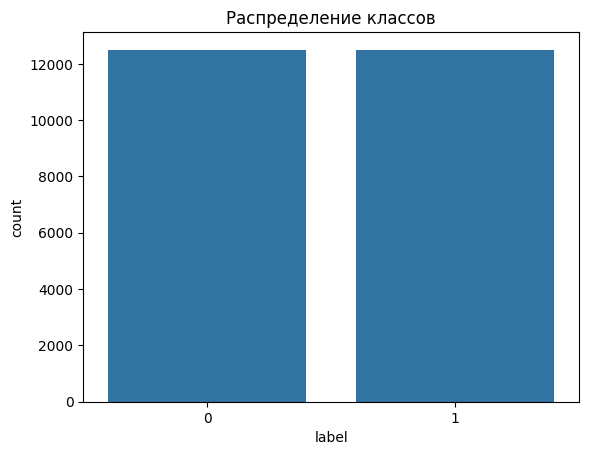

In [ ]:
sns.countplot(x=train_df["label"])
plt.title("Распределение классов")
plt.show()

# **5. Базовая модель: TF-IDF + Logistic Regression**

In [ ]:
# Ограничиваем словарь до 10000 наиболее частых слов,
# чтобы уменьшить размерность признакового пространства
vectorizer = TfidfVectorizer(max_features=10000)

# Преобразуем текст в TF-IDF векторы
X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

# Метки классов
y_train = train_df["label"]
y_test = test_df["label"]

# Логистическая регрессия — линейная модель для бинарной классификации
# увеличиваем число итераций для сходимости
model_lr = LogisticRegression(max_iter=1000)

# Обучение модели
model_lr.fit(X_train, y_train)

In [ ]:
# Логистическая регрессия — линейная модель для бинарной классификации
# увеличиваем число итераций для сходимости
model_lr = LogisticRegression(max_iter=1000)

# Обучение модели
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
preds_lr = model_lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, preds_lr)

print("Accuracy:", accuracy_lr)

Accuracy: 0.88368


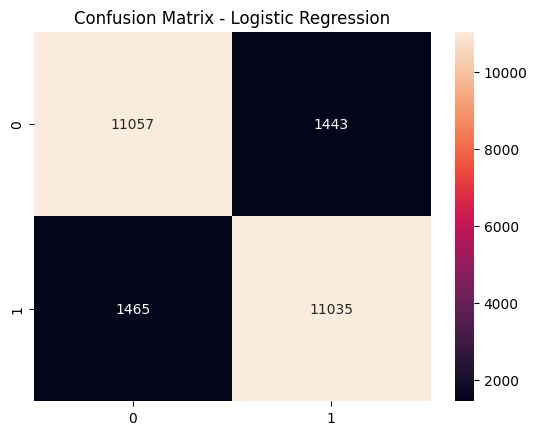

In [ ]:
cm = confusion_matrix(y_test, preds_lr)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# **6. Модель BERT**

In [ ]:
# Загружаем предобученный токенизатор BERT
# он разбивает текст на токены и приводит к нужному формату
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
# Загружаем предобученную модель BERT для задачи классификации
# num_labels=2 — бинарная классификация (позитив/негатив)
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# **7. Обучение моделей**

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=50,
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
# Trainer — высокоуровневый API HuggingFace
# управляет обучением, валидацией и логированием
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"].shuffle(seed=42).select(range(5000)),
    eval_dataset=dataset["test"].shuffle(seed=42).select(range(1000)),
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.353182,0.369842,0.841000,0.804067,0.891393,0.845481


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=625, training_loss=0.4620389595031738, metrics={'train_runtime': 142.1177, 'train_samples_per_second': 35.182, 'train_steps_per_second': 4.398, 'total_flos': 328888819200000.0, 'train_loss': 0.4620389595031738, 'epoch': 1.0})

# **8. Оценка результатов**

In [ ]:
results = trainer.evaluate()
results

{'eval_loss': 0.3698420524597168,
 'eval_accuracy': 0.841,
 'eval_precision': 0.8040665434380776,
 'eval_recall': 0.8913934426229508,
 'eval_f1': 0.8454810495626822,
 'eval_runtime': 7.2958,
 'eval_samples_per_second': 137.065,
 'eval_steps_per_second': 17.133,
 'epoch': 1.0}

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "BERT"],
    "Accuracy": [accuracy_lr, results["eval_accuracy"]],
    "Precision": [None, results["eval_precision"]],
    "Recall": [None, results["eval_recall"]],
    "F1-score": [None, results["eval_f1"]],
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.88368,NaN,NaN,NaN
1,BERT,0.84100,0.804067,0.891393,0.845481


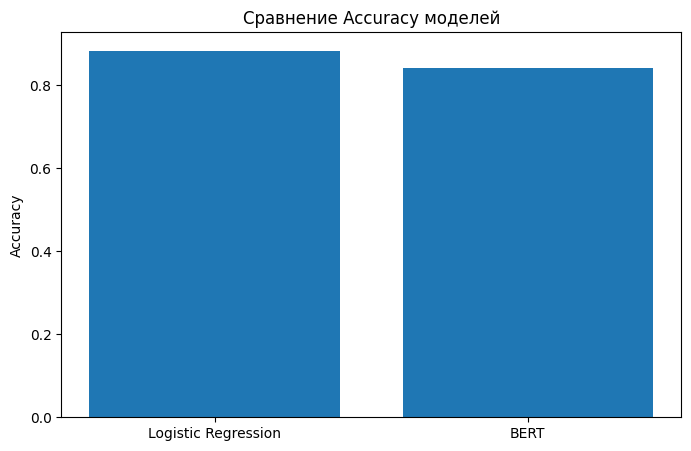

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Сравнение Accuracy моделей")
plt.ylabel("Accuracy")
plt.show()

Как видно из результатов, обе модели демонстрируют высокое качество классификации. Однако различия в метриках следует интерпретировать с учётом объёма обучающих данных и количества эпох обучения.

In [ ]:
import torch

text = "This movie was amazing, emotional and beautifully acted."

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

# переносим входы на то же устройство, где модель
inputs = {k: v.to(device) for k, v in inputs.items()}

model.eval()
with torch.no_grad():
    outputs = model(**inputs)

pred = torch.argmax(outputs.logits, dim=1).item()

print("Предсказанный класс:", pred)
print("Позитивный отзыв" if pred == 1 else "Негативный отзыв")

Предсказанный класс: 1
Позитивный отзыв


# **9. Анализ ошибок**

In [ ]:
errors_lr = test_df.copy()
errors_lr["pred"] = preds_lr
errors_lr["is_error"] = errors_lr["label"] != errors_lr["pred"]

errors_lr[errors_lr["is_error"]].head(10)

,text,label,pred,is_error
4,"First off let me say, If you haven't enjoyed a...",0,1,True
11,"Blind Date (Columbia Pictures, 1934), was a de...",0,1,True
18,"Ben, (Rupert Grint), is a deeply unhappy adole...",0,1,True
25,I of course saw the previews for this at the b...,0,1,True
28,Four things intrigued me as to this film - fir...,0,1,True
32,I'm the type of guy who loves hood movies from...,0,1,True
41,Widow hires a psychopath as a handyman. Sloppy...,0,1,True
46,"Okay, so it was never going to change the worl...",0,1,True
61,This film features two of my favorite guilty p...,0,1,True
63,This only gets bashed because it stars David H...,0,1,True


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, preds_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



# **10. Сохранение моделей**

In [ ]:
import joblib

joblib.dump(model_lr, "logistic_regression_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
trainer.save_model("./bert_imdb_model")
tokenizer.save_pretrained("./bert_imdb_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bert_imdb_model/tokenizer_config.json', './bert_imdb_model/tokenizer.json')

# **11. Выводы**

## Выводы

В данной работе была исследована задача автоматической классификации текстов на примере отзывов о фильмах из датасета IMDb. В рамках эксперимента были реализованы и сравнены два подхода: классический метод машинного обучения TF-IDF + Logistic Regression и современная трансформерная модель BERT.

Базовая модель Logistic Regression использует представление текста в виде TF-IDF-векторов, которые отражают важность слов в документе. Данный подход отличается простотой реализации, высокой скоростью обучения и небольшими вычислительными требованиями.

Модель BERT представляет собой глубокую нейронную сеть на основе архитектуры трансформеров, которая способна учитывать контекст слов в предложении благодаря механизму self-attention. Это позволяет модели лучше понимать семантику текста.

По результатам эксперимента модель Logistic Regression показала более высокую точность классификации по сравнению с BERT. Однако это не свидетельствует о превосходстве классической модели, а обусловлено ограничениями эксперимента: BERT обучался только одну эпоху и на уменьшенной подвыборке данных.

При обучении на полном наборе данных и увеличении числа эпох трансформерные модели, как правило, демонстрируют более высокое качество за счёт лучшего учёта контекста.
Несмотря на это, трансформерные модели обладают большим потенциалом и при обучении на полном наборе данных и большем числе эпох могут значительно превосходить классические методы машинного обучения.

К основным ограничениям данной работы можно отнести использование сокращённого объёма данных для обучения BERT, отсутствие подбора гиперпараметров и ограниченные вычислительные ресурсы.

В дальнейшем работу можно улучшить за счёт увеличения числа эпох обучения, использования полного обучающего набора данных, подбора оптимальных гиперпараметров, а также более подробного анализа ошибок моделей.